# MFIS $_{t-1}$ + DMO $_{t}\rightarrow$ MFIS $_t$

In [67]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.core.enums import MileStone, DataFrequency, PatientDataType
from src.evaluation import Evaluation
from src.core.normaliser import Normaliser
from sklearn.preprocessing import MinMaxScaler
from src.core.data_transforms import Transform
from src.model import DMORandomForestRegressor
from src.train import XVRandomForest

import numpy as np
import torch

In [68]:
K_FOLDS = 5
N_VISITS = 4

In [69]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
]

In [71]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
    #static_features=static_features
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [72]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/home/gwilym-rutherf

In [73]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [74]:
dmo_data.shape

torch.Size([428, 4, 7, 5])

In [75]:
# remove missing labels
patient_indexs = []
patient, visit, day, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

dmo_data = dmo_data[patient_indexs]
dmo_labels = dmo_labels[patient_indexs]

In [76]:
dmo_data = dmo_data.mean(axis=2)

In [77]:
fatigue_labels = dmo_labels

In [78]:
# Min max normalise all fatigue values
physical_subset_max = 36
fatigue_labels = fatigue_labels / physical_subset_max

In [79]:
prev_fatigue = fatigue_labels[:, :-1, :]
current_features = dmo_data[:, 1:, :]
target_y = fatigue_labels[:, 1:, :]

In [80]:
X_combined = torch.cat((current_features, prev_fatigue), dim=2)

In [ ]:
input_data = X_combined.reshape(-1, 25)
label_data = target_y.reshape(-1)

In [83]:
input_data.shape

torch.Size([1284, 6])

In [84]:
label_data.shape

torch.Size([1284])

In [87]:
# shuffle
patients, *other = input_data.shape
generator = torch.Generator()
generator.manual_seed(1234)
random_permutation = torch.randperm(patients, generator=generator)

input_data = input_data[random_permutation]
label_data = label_data[random_permutation]

In [103]:
fatigue_input_split = torch.tensor_split(input_data, K_FOLDS)
fatigue_label_split = torch.tensor_split(label_data, K_FOLDS)

prediction_arr = []
actual_arr = []
for split_i in range(K_FOLDS):
    test_label = fatigue_label_split[split_i]
    test_data = fatigue_input_split[split_i]

    train_label = torch.cat(
        [fatigue_label_split[i] for i in range(0, K_FOLDS) if i != split_i]
    )
    train_data = torch.cat(
        [fatigue_input_split[i] for i in range(0, K_FOLDS) if i != split_i]
    )
    
    rf_model = DMORandomForestRegressor(n_trees=500)

    rf_model.train(train_data, train_label)
    score = rf_model.score(test_data, test_label)
    print(score)
    
    prediction = torch.tensor(rf_model.predict(test_data))
    prediction = (prediction * physical_subset_max)
    
    actual = (test_label * physical_subset_max)
    
    prediction_arr.append(prediction)
    actual_arr.append(actual)

ValueError: Found input variables with inconsistent numbers of samples: [1025, 1027]

In [89]:
prediction = torch.cat(prediction_arr)
actual = torch.cat(actual_arr)

{'accuracy': 0.0132398753894081, 'Mean Squared Error': 31.35850715637207, 'Mean Absolute Error': 4.343484878540039, 'R^2': 0.5466775583641184}


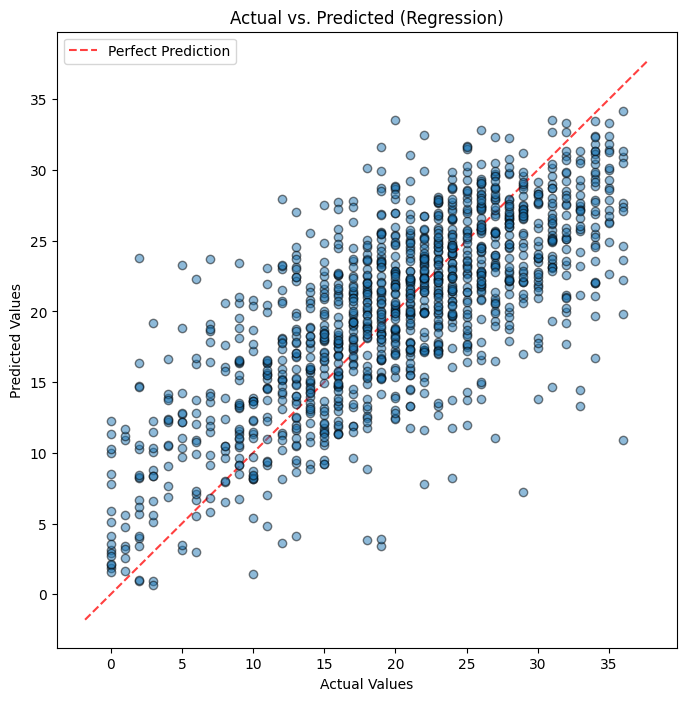

In [90]:
evaluation = Evaluation(prediction, actual)
print(evaluation.compute_all_metrics())
evaluation.evaluation_plot().show()

In [91]:
import shap

dmo_features += ["prev MFIS"]
features = dmo_features
print(features)

random_forest_model = rf_model.random_forest
test_input_numpy = torch.Tensor.numpy(test_input)

explainer = shap.TreeExplainer(random_forest_model)
shap_values = explainer.shap_values(test_input_numpy)
shap.summary_plot(
    shap_values,
    test_input_numpy,
    feature_names=features ,
)

['cadence_30_p90_d', 'cadence_30_avg_d', 'ws_30_p90_d', 'strlen_1030_avg_d', 'cadence_all_avg_d', 'prev MFIS']


NameError: name 'test_input' is not defined

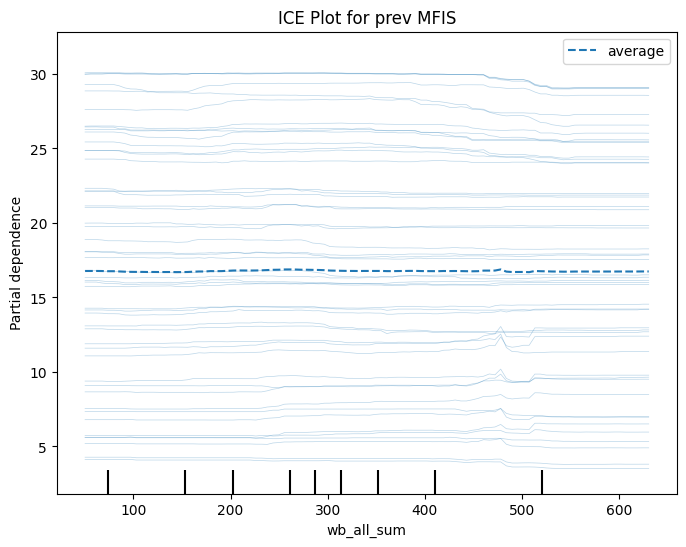

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

feature_index = 0

test_numpy = test_input.numpy()

fig, ax = plt.subplots(figsize=(8, 6))

display = PartialDependenceDisplay.from_estimator(
    random_forest_model, 
    test_numpy, 
    features=[feature_index],
    feature_names=dmo_features,
    kind='both', 
    subsample=50,
    ax=ax
)

ax.set_title("ICE Plot for prev MFIS")
plt.show()